# Combo Lock

In [1]:
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import numpy as np
file_vanilla = "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1_sc_True_belief_prompting_False/global_step_140_sc_True_belief_prompting_False_inference/train_gen.txt"
file_vanilla_step_80 = "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1_sc_True_belief_prompting_False/global_step_80_sc_True_belief_prompting_False_inference/train_gen.txt"
file_belief_prompting = "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1_sc_True_belief_prompting_True/global_step_140_sc_True_belief_prompting_True_inference/train_gen.txt" # REDOING DATA GENERATION.
file_ABBEL_seed_1 = "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_140_inference/train_gen.txt"
file_ABBEL_seed_2 = "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed2/global_step_140_sc_False_belief_prompting_True_inference/train_gen.txt"

def get_df_from_train_gen(file: str):
    raw_jl = open(file, 'r', encoding='utf-8').read()

    import json, sys, pathlib

    json_list = []
    for i, raw_json in enumerate(raw_jl.strip().split("\n}")):
        if raw_json.strip():
            json_list.append(json.loads(raw_json + "\n}"))
    df = pd.DataFrame(json_list)
    return df


def get_regret_from_train_gen(file: str, max_attempts: int, is_sc=True):

    df = get_df_from_train_gen(file)
    # print(df.columns)
    if is_sc:
        reward_per_traj_data = df.episode_rewards.values[0]
        # print(reward_per_traj_data)
        ...
    else:
        # need to deal with the data in a special way to deduplicate the rewards based on the trajectory ids.
        trajectory_uid_to_some_context = dict()
        reward_per_traj_data = []
        context_rewards = df.episode_rewards.values[0]
        for index, trajectory_uid in enumerate(df.traj_uid[0]):
            # print(index, trajectory_uid)
            if trajectory_uid in trajectory_uid_to_some_context:
                continue
            trajectory_uid_to_some_context[trajectory_uid] = index
            reward_per_traj_data.append(context_rewards[index])
        ...
    # then we compute the 
    regret_arr_per_traj = []
    # print(np.mean(reward_per_traj_data))
    for reward in reward_per_traj_data:
        # invert the attempts -> reward calculation. 
        # reward = (max_attempts - attempts + 1) / max_attempts => attempts = -reward * max_attempts + 1 + max_attempts
        if reward == -1.0:
            attempts = 16
        else:
            attempts = int(1 + max_attempts - reward * max_attempts)
        # print(attempts)
        regret_arr_per_traj.append([1] * attempts + [0] * (max_attempts - attempts))
    # pprint(regret_arr_per_traj)
    avg_regret = np.mean(regret_arr_per_traj, axis=0).cumsum()
    sem_regret = np.std(regret_arr_per_traj, axis=0) / np.sqrt(len(avg_regret)) * 1.96
    return avg_regret, sem_regret
    # data # this should be the turn counts per game padded to the game length
def plt_std_err(name, vals, errs):
    plt.errorbar(x=list(range(len(vals))), y=vals, yerr=errs, label=name)


# plt_std_err(*(("Vanilla",) + get_regret_from_train_gen(file_vanilla, 16, is_sc=False)))
# plt_std_err(*(("Vanilla (step 80)",) + get_regret_from_train_gen(file_vanilla_step_80, 16, is_sc=False)))
# plt_std_err(*(("Belief Prompting",) + get_regret_from_train_gen(file_belief_prompting, 16, is_sc=True)))
# plt_std_err(*(("ABBEL seed 1",) + get_regret_from_train_gen(file_ABBEL_seed_1, 16, is_sc=False)))
# plt_std_err(*(("ABBEL seed 2",) + get_regret_from_train_gen(file_ABBEL_seed_2, 16, is_sc=False)))

# if I just want to do every step of training for some model like just vanilla.
for name, file in [
    ("step 0", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__sc_True_belief_prompting_False_inference/train_gen.txt"),
    ("step 20", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1_sc_True_belief_prompting_False/global_step_20_sc_True_belief_prompting_False_inference/train_gen.txt"),
    ("step 40", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1_sc_True_belief_prompting_False/global_step_40_sc_True_belief_prompting_False_inference/train_gen.txt"),
    ("step 60", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1_sc_True_belief_prompting_False/global_step_60_sc_True_belief_prompting_False_inference/train_gen.txt"),
    ("step 80", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1_sc_True_belief_prompting_False/global_step_80_sc_True_belief_prompting_False_inference/train_gen.txt"),
    ("step 100", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1_sc_True_belief_prompting_False/global_step_100_sc_True_belief_prompting_False_inference/train_gen.txt"),
    ("step 120", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1_sc_True_belief_prompting_False/global_step_120_sc_True_belief_prompting_False_inference/train_gen.txt"),
    ("step 140", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1_sc_True_belief_prompting_False/global_step_140_sc_True_belief_prompting_False_inference/train_gen.txt"),
    ]:
    # plt_std_err(*(("Vanilla "+name,) + get_regret_from_train_gen(file, 16, is_sc=False)))
    ...
for name, file in [
    ("step 0", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__sc_False_belief_prompting_True_inference/train_gen.txt"),
    ("step 20", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_20_inference/train_gen.txt"),
    ("step 40", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_40_inference/train_gen.txt"),
    ("step 60", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_60_inference/train_gen.txt"),
    ("step 80", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_80_inference/train_gen.txt"),
    ("step 100", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_100_inference/train_gen.txt"),
    ("step 120", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_120_inference/train_gen.txt"),
    ("step 140", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_140_inference/train_gen.txt"),
    ]:

    # plt_std_err(*(("ABBEL seed 1 "+name,) + get_regret_from_train_gen(file, 16, is_sc=False)))
    
    ...
# plt.ylim(top=15, bottom=0)
# plt.legend()

def get_qualitatives(file, is_sc):
    df = get_df_from_train_gen(file)
    # print(df)
    # just looking for full trajectories
    if is_sc:
        trajectories = df.full_trajectory_strings.values[0]
        df = pd.DataFrame(df.iloc[0].to_dict())
    else:
        # need to deal with the data in a special way to deduplicate the rewards based on the trajectory ids.
        trajectory_uid_to_some_context = dict()
        trajectories = []
        indices = []
        full_trajectory_strings = df.full_trajectory_strings.values[0]
        for index, (trajectory_uid, step) in enumerate(zip(df.traj_uid[0], df.step[0])):
            if trajectory_uid in trajectory_uid_to_some_context:
                if trajectory_uid_to_some_context[trajectory_uid] < (step, index):
                    trajectory_uid_to_some_context[trajectory_uid] = (step, index) # gets the last step of every trajectory
                continue
            trajectory_uid_to_some_context[trajectory_uid] = (step, index)
        indices = [i for _,i in trajectory_uid_to_some_context.values()]
        trajectories = [full_trajectory_strings[i] for i in indices]
        df = pd.DataFrame(df.iloc[0].to_dict()).iloc[indices]
    return df


# df = get_qualitatives("/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__sc_True_belief_prompting_False_inference/train_gen.txt", True)
# df = get_qualitatives("/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__sc_False_belief_prompting_True_inference/train_gen.txt", False)
df = get_qualitatives("/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_140_inference/train_gen.txt", False)



In [ ]:
# Plotly version of the chart with requested colors and trace order.
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

# Data from the user
X = [0, 20, 40, 60, 80, 100, 120, 140]
seed_1_ABBEL_data = [21.09, 49.22, 50.78, 60.55, 65.82, 69.14, 69.92, 72.27]
seed_2_ABBEL_data = [21.09, 59.6, 64.45, 65.82, 68.16, 64.26, 65.23, 66.8]
vanilla_performance = [41.80, 54, 66, 70, 79, 75.78, 74.2, 71.7]
belief_prompting_differenent_messages_performance = [45.12, 58, 62.6, 68.75, 67.7, 60.156, 74.8, 78.5]

def standard_error(p, n=512):
    return np.sqrt(p * (100 - p) / n)

# Compute standard errors (percent scale, matching the inputs)
seed_1_err = [standard_error(p) for p in seed_1_ABBEL_data]
seed_2_err = [standard_error(p) for p in seed_2_ABBEL_data]
vanilla_err = [standard_error(p) for p in vanilla_performance]
belief_err = [standard_error(p) for p in belief_prompting_differenent_messages_performance]

# Colors: px.colors.qualitative.Dark24 indices [1, 6, 15, 19]
palette = px.colors.qualitative.Dark24
colors = [palette[i] for i in [1, 6, 15, 19]]

fig = go.Figure()

# Trace order: Vanilla, Belief Prompting, ABBEL seed 1, ABBEL seed 2
fig.add_trace(go.Scatter(
    x=X, y=vanilla_performance, mode="lines+markers", name="Vanilla",
    line=dict(color=colors[0]),
    error_y=dict(type="data", array=vanilla_err, visible=True)
))
fig.add_trace(go.Scatter(
    x=X, y=belief_prompting_differenent_messages_performance, mode="lines+markers", name="Belief Prompting",
    line=dict( color=colors[1], dash="solid"), marker=dict( symbol="square"),
    error_y=dict(type="data", array=belief_err, visible=True)
))
fig.add_trace(go.Scatter(
    x=X, y=seed_1_ABBEL_data, mode="lines+markers", name="ABBEL seed 1",
    line=dict(color=colors[2]),
    error_y=dict(type="data", array=seed_1_err, visible=True)
))
fig.add_trace(go.Scatter(
    x=X, y=seed_2_ABBEL_data, mode="lines+markers", name="ABBEL seed 2",
    line=dict(color=colors[3]),
    error_y=dict(type="data", array=seed_2_err, visible=True)
))

fig.update_layout(
    title={'text': "Test Performance Over Training", 'x': 0.5, 'xanchor': 'center'},
    xaxis_title="Training Step",
    yaxis_title="Test Success Rate (%)",
    xaxis=dict(range=[-5, 145], gridcolor="rgba(0,0,0,0.1)"),
    yaxis=dict(gridcolor="rgba(0,0,0,0.1)"),
    # legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white",
    # width=900,
    # height=550,
    # margin=dict(l=60, r=20, t=70, b=60)
)

# Save to files
# html_path = "/mnt/data/success_plot_plotly.html"
# png_path = "/mnt/data/success_plot_plotly.png"
pdf_path = "figures/success_plot.pdf"
# fig.write_html(html_path, include_plotlyjs="cdn")

# Try saving PNG (requires kaleido). Wrap in try/except in case it's not available.
png_saved = True
fig.write_image(pdf_path)

# try:
#     fig.write_image(png_path, scale=2, width=1200, height=700)
# except Exception as e:
#     png_saved = False
#     png_error = repr(e)

# Show the interactive figure in the notebook
# fig, {"html_path": html_path, "png_path": png_path, "png_saved": png_saved}


In [ ]:
import re

# trajectory_string = df[df.episode_lengths == 32].iloc[0].full_trajectory_strings
# belief_matches = re.findall(r'(<belief>((?!<belief>).)*?</belief>\n==========)', trajectory_string, re.DOTALL)
# #belief_matches = re.findall(r'<belief>(.*?)</belief>\n==========', trajectory_string, re.DOTALL)
# for i, belief in enumerate(belief_matches):
#     print(f"Belief {i+1}:")
#     print(belief[0])
#     print("---")
def get_all_beliefs(trajectory_string):
    actions = trajectory_string.split('Your last action:\n<action>invalid action</action>\nEnvironment feedback:\nCould not parse response')
    belief_matches = []
    for i, action in enumerate(actions):
        action_belief_matches = re.findall(r'(<belief>((?!<belief>).)*?</belief>\n==========)', action, re.DOTALL)
        if len(action_belief_matches) > 1:
            belief_matches.extend(action_belief_matches[:-1]) # remove the last belief, because it came right before an invalid action
    beliefs = [belief[0] for belief in belief_matches]
    return beliefs

def get_all_belief_lens(trajectory_string):
    beliefs = get_all_beliefs(trajectory_string)    
    belief_lens = [len(belief)-len('<belief></belief>\n==========') for belief in beliefs]
    return belief_lens

def get_mean_belief_length(trajectory_string):
    belief_lens = get_all_belief_lens(trajectory_string)
    if len(belief_lens) == 0:
        return np.nan
    return np.mean(belief_lens)

def get_checkpoint_mean_belief_length(df):
    mean_belief_lengths = df.full_trajectory_strings.apply(get_mean_belief_length)
    valid_lengths = mean_belief_lengths.dropna()
    return np.mean(valid_lengths), np.std(valid_lengths)/np.sqrt(len(valid_lengths))

df_beliefs = pd.DataFrame(columns=['checkpoint', 'attempt', 'belief_length'])
checkpoints = []
belief_lengths = []
for name, file in [
    ("step 0", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__sc_False_belief_prompting_True_inference/train_gen.txt"),
    ("step 20", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_20_inference/train_gen.txt"),
    ("step 40", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_40_inference/train_gen.txt"),
    ("step 60", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_60_inference/train_gen.txt"),
    ("step 80", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_80_inference/train_gen.txt"),
    ("step 100", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_100_inference/train_gen.txt"),
    ("step 120", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_120_inference/train_gen.txt"),
    ("step 140", "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_140_inference/train_gen.txt"),
    ]:
    df = get_qualitatives(file, False)
    checkpoints.append(int(name.split(' ')[1]))
    belief_lengths.append(get_checkpoint_mean_belief_length(df))
    all_belief_lens = df.full_trajectory_strings.apply(get_all_belief_lens)
    for trajectory in all_belief_lens:
        for attempt_i, belief_len in enumerate(trajectory):
            df_beliefs = pd.concat([df_beliefs, pd.DataFrame({'checkpoint': [checkpoints[-1]], 'attempt': [attempt_i]+1, 'belief_length': [belief_len]})])

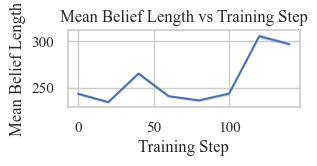

In [ ]:
mean_df = df_beliefs.groupby(['checkpoint'])['belief_length'].agg(['mean', 'std', 'count']).reset_index()
mean_df['sem'] = mean_df['std'] / mean_df['count'].apply(lambda n: np.sqrt(n) if n > 0 else 1)
plt.plot(mean_df.checkpoint, mean_df['mean'])
plt.fill_between(mean_df.checkpoint, 
                 (mean_df['mean']-mean_df['sem']).astype(float), 
                 (mean_df['mean']+mean_df['sem']).astype(float), 
                 alpha=0.2)
plt.xlabel('Training Step')
plt.ylabel('Mean Belief Length')
plt.title('Mean Belief Length vs Training Step')
plt.gcf().set_size_inches(3, 1)
plt.show()

In [ ]:
import plotly.graph_objects as go
import plotly.colors as pc

fig = go.Figure()
colors = pc.sample_colorscale('viridis', [i/7 for i in range(8)])

 # Add full history line
fig.add_trace(
    go.Scatter(
        x=np.arange(1, 14),
        y=len("Your last action:\n<action>['h', 'r', 't']</action>\nEnvironment feedback:\nh is not in Position 1, but is in the lock\n\nr is not in the lock\nt is in Position 3!\n")*np.arange(1, 14),
        mode='lines+markers',
        name='History length',
        legendgroup='history',
        showlegend=True,  # only show legend once
        line=dict(color='gray', width=2, dash='dot'),
        marker=dict(color='gray')
    ))

for checkpoint_i, color in zip([0, 20, 40, 60, 80, 100, 120, 140], colors):
    mean_df_attempts = df_beliefs[df_beliefs.checkpoint == checkpoint_i].groupby(['attempt'])['belief_length'].agg(['mean', 'std', 'count']).reset_index()
    mean_df_attempts['sem'] = mean_df_attempts['std'] / mean_df_attempts['count'].apply(lambda n: np.sqrt(n) if n > 0 else 1)
    
    # Add main line
    fig.add_trace(go.Scatter(
        x=mean_df_attempts.attempt,
        y=mean_df_attempts['mean'],
        mode='lines',
        name=f'Train step {checkpoint_i}',
        line=dict(color=color),
        showlegend=True
    ))
    # Add shaded region for error bounds
    error_lower = mean_df_attempts['mean'] - mean_df_attempts['sem']
    error_upper = mean_df_attempts['mean'] + mean_df_attempts['sem']
    x = mean_df_attempts.attempt
    # Add the lower error bound trace
    fig.add_trace(go.Scatter(
        x=x,
        y=error_lower,
        mode='lines',
        line=dict(width=0), # Hide the line for the lower bound
        showlegend=False,
        hoverinfo="skip",
        legendgroup=str(checkpoint_i)
    ))

    # Add the upper error bound trace and fill to the lower bound
    fig.add_trace(go.Scatter(
        x=x,
        y=error_upper,
        mode='lines',
        fill='tonexty', # Fill the area between this trace and the previous one
        fillcolor=color.replace('rgb', 'rgba').replace(')', ', 0.2)'),
        line=dict(width=0), # Hide the line for the upper bound
        hoverinfo="skip",
        showlegend=False,
        legendgroup=str(checkpoint_i)
    ))
    
fig.update_layout(
    xaxis_title='Environment Steps',
    yaxis_title='Mean Belief Length (chars)',
    xaxis=dict(range=[1, 13], dtick=1),
    yaxis=dict(range=[150, 400]),
    legend=dict(orientation='v', font=dict(size=14)),
    font=dict(family='Times New Roman', size=16, color='black'),
    template='plotly_white',
    width=600,
    height=470
)

fig.show()
fig.write_image('figures/belief_length_over_training.pdf', width=600, height=470)

In [ ]:
df_0 = get_qualitatives("/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__sc_False_belief_prompting_True_inference/train_gen.txt", False)
df_140 = get_qualitatives("/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/grpo_qwen2.5_7b_b256_t_1.0_v_qawsedrftgyhujik_m_16_ckpt__seed1/global_step_140_inference/train_gen.txt", False)

beliefs_0 = df_0.full_trajectory_strings.apply(get_all_beliefs)
beliefs_140 = df_140.full_trajectory_strings.apply(get_all_beliefs)

In [ ]:
pprint(beliefs_0.iloc[4])

["<belief>Character set: ['a', 's', 'd', 'r', 'f', 't', 'g', 'y', 'h', 'u', "
 "'j', 'i', 'k']\n"
 'Positions 1, 2, and 3 must be filled with unique characters from the above '
 'set.\n'
 "No character from the previous query ('q', 'w', 'e') is in the "
 'combination.</belief>\n'
 '==========',
 "<belief>character set: ['a', 's', 'd', 'r', 'f', 't', 'g', 'y', 'h', 'u', "
 "'j', 'i', 'k']\n"
 'positions 1, 2, and 3 must be filled with unique characters from the above '
 'set.\n'
 "no character from the previous query ('q', 'w', 'e') is in the "
 'combination.</belief>\n'
 '==========',
 '<belief>\n'
 "character set: ['s', 'r', 't', 'f', 'y', 'h', 'u', 'j', 'i', 'k']\n"
 'positions 1 and 2 must be filled with unique characters from the above set.\n'
 "The character 'g' is in Position 3.\n"
 "Characters 'a' and 'd' are not in the lock.\n"
 '</belief>\n'
 '==========',
 '<belief>\n'
 "character set: ['t', 'f', 'y', 'h', 'u', 'j', 'i', 'k']\n"
 'positions 1 and 2 must be filled with unique 

In [ ]:
pprint(beliefs_140.iloc[3])

["<belief>The characters 'w', 'e', and 'r' are not in the combination. The set "
 "of possible characters for positions 1, 2, and 3 is now ['q', 'a', 's', 'd', "
 "'f', 't', 'g', 'y', 'h', 'u', 'j', 'i', 'k']. We need to construct a new "
 'query using these characters.</belief>\n'
 '==========',
 '<belief>\n'
 "The characters 'w', 'e', 'r', 'q', 'a', 's' are not in the combination. The "
 "characters 'd', 'f', 't', 'g', 'y', 'h', 'u', 'j', 'i', 'k' are the only "
 'possible candidates for the combination. We need to construct a new query '
 'using these characters to get further feedback.\n'
 '</belief>\n'
 '==========',
 "<belief>The characters 'd', 't', and 'w' are not in the combination. The "
 "possible characters are now 'e', 'r', 'q', 'a', 's', 'g', 'y', 'h', 'u', "
 "'j', 'i', and 'k'. From the feedback, 'f' is in the lock and either in "
 "Position 1 or Position 3, but not in Position 2. Therefore, 'f' must be in "
 'either Position 1 or 3. We can form the following queries to

In [ ]:
# Interactive rollout explorer widget for a pandas DataFrame named `df`.
# If `df` is not yet defined, this cell will create a tiny mock example so you can see the UI.
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, clear_output
import ipywidgets as widgets
import matplotlib.pyplot as plt

# Try to find a dataframe named `df`; if missing, make a small demo one.
if "df" not in globals():
    rng = np.random.default_rng(0)
    n = 40
    df = pd.DataFrame({
        "uid": [f"uid-{i:04d}" for i in range(n)],
        "traj_uid": [f"traj-{i:04d}" for i in range(n)],
        "episode_lengths": rng.integers(1, 16, size=n),
        "success_rate": rng.random(n),
        "episode_rewards_mean": rng.normal(loc=0.0, scale=0.5, size=n),
        "full_trajectory_strings": [
            "system: You will determine the correct combination. Attempt {}. User: ...".format(i)
            + (" target=unlock" if i % 7 == 0 else "")
            + (" belief failure" if i % 11 == 0 else "")
            for i in range(n)
        ],
        "is_action_valid": rng.choice([True, False], size=n),
        "data_source": "text",
    })
    display(Markdown("> **No `df` detected.** Using a small demo DataFrame so you can try the widget. "
                     "Replace `df` with your rollout DataFrame and re-run this cell."))

# Core columns we will try to use if present
COL_EP_LEN = "episode_lengths"
COL_TEXT = "full_trajectory_strings"

missing_cols = [c for c in [COL_EP_LEN, COL_TEXT] if c not in df.columns]
if missing_cols:
    display(Markdown(f"**Note:** Your DataFrame is missing expected column(s): `{missing_cols}`. "
                     "The widget will still load, but some filters will be disabled."))

# ------------ Widgets ------------
# Episode length range filter
if COL_EP_LEN in df.columns and pd.api.types.is_numeric_dtype(df[COL_EP_LEN]):
    ep_min, ep_max = int(df[COL_EP_LEN].min()), int(df[COL_EP_LEN].max())
    ep_range = widgets.IntRangeSlider(
        value=[ep_min, ep_max],
        min=ep_min, max=max(ep_max, ep_min + 1), step=1,
        description='Episode len:',
        continuous_update=False, layout=widgets.Layout(width='500px')
    )
else:
    ep_range = widgets.IntRangeSlider(value=[0, 0], min=0, max=0, step=1, description='Episode len:')
    ep_range.disabled = True

# "Filter out (exclude) runs that terminated within ≤ N attempts" control
exclude_short_chk = widgets.Checkbox(value=False, description="Exclude runs with length ≤ N")
exclude_short_val = widgets.IntText(value=3, description="N:", layout=widgets.Layout(width='180px'))

# Text search filters for trajectory strings
search_box = widgets.Text(
    value='',
    placeholder='Substring or regex (use Regex mode below)',
    description='Search:',
    layout=widgets.Layout(width='500px')
)
regex_chk = widgets.Checkbox(value=False, description="Regex")
case_chk = widgets.Checkbox(value=False, description="Case sensitive")
all_terms_chk = widgets.Checkbox(value=False, description="Match ALL comma-separated terms")

# Columns to show in overview table
default_overview_cols = [c for c in [
    "uid", "traj_uid", "is_action_valid", "data_source",
    "episode_rewards", "success_rate", COL_EP_LEN, COL_TEXT
] if c in df.columns]
all_cols_options = [(c, c) for c in df.columns]
overview_cols_select = widgets.SelectMultiple(
    options=all_cols_options,
    value=tuple(default_overview_cols),
    description='Columns:',
    layout=widgets.Layout(width='350px', height='160px')
)

# Buttons
apply_btn = widgets.Button(description="Apply Filters", button_style='primary', icon='filter')
open_table_btn = widgets.Button(description="Open filtered data in table viewer", icon='table')
save_csv_btn = widgets.Button(description="Save filtered CSV", icon='save')
csv_name = widgets.Text(value="filtered_rollouts.csv", description="Filename:", layout=widgets.Layout(width='300px'))

# Per-example selector
example_selector = widgets.Dropdown(
    options=[],
    description='Example:',
    layout=widgets.Layout(width='400px')
)

# Outputs
summary_out = widgets.Output()
table_out = widgets.Output()
detail_out = widgets.Output()
plot_out = widgets.Output()

# ------------ Filtering logic ------------
def _filter_df():
    d = df
    # Episode length range
    if not ep_range.disabled:
        lo, hi = ep_range.value
        d = d[(d[COL_EP_LEN] >= lo) & (d[COL_EP_LEN] <= hi)]
    # Exclude short episodes ≤ N
    if exclude_short_chk.value and not ep_range.disabled:
        N = int(exclude_short_val.value)
        d = d[d[COL_EP_LEN] > N]
    # Text search
    if COL_TEXT in d.columns:
        query = search_box.value.strip()
        if query:
            if all_terms_chk.value:
                # split by commas, trim, require all terms present
                parts = [p.strip() for p in query.split(",") if p.strip()]
                if parts:
                    mask = pd.Series(True, index=d.index)
                    for term in parts:
                        if regex_chk.value:
                            mask &= d[COL_TEXT].astype(str).str.contains(term, regex=True, case=case_chk.value, na=False)
                        else:
                            mask &= d[COL_TEXT].astype(str).str.contains(term, regex=False, case=case_chk.value, na=False)
                    d = d[mask]
            else:
                if regex_chk.value:
                    d = d[d[COL_TEXT].astype(str).str.contains(query, regex=True, case=case_chk.value, na=False)]
                else:
                    d = d[d[COL_TEXT].astype(str).str.contains(query, regex=False, case=case_chk.value, na=False)]
    return d

# ------------ Update handlers ------------
def refresh_views(_=None):
    filtered = _filter_df()
    # summary
    with summary_out:
        clear_output()
        display(Markdown(f"### Summary — {len(filtered)} rows"))
        # Simple stats
        stats_lines = []
        if "success_rate" in filtered.columns:
            stats_lines.append(f"- Mean success_rate: **{filtered['success_rate'].mean():.4f}**")
        if COL_EP_LEN in filtered.columns:
            stats_lines.append(f"- Episode length: min **{filtered[COL_EP_LEN].min()}**, "
                               f"mean **{filtered[COL_EP_LEN].mean():.2f}**, max **{filtered[COL_EP_LEN].max()}**")
        if "episode_rewards_mean" in filtered.columns:
            stats_lines.append(f"- Mean reward: **{filtered['episode_rewards_mean'].mean():.4f}**")
        if stats_lines:
            display(Markdown("\n".join(stats_lines)))
    # table (head preview)
    with table_out:
        clear_output()
        cols = list(overview_cols_select.value) if overview_cols_select.value else list(filtered.columns)
        preview = filtered[cols].head(20) if len(filtered) > 0 else filtered[cols]
        display(Markdown("**Preview (first 20 rows):**"))
        display(preview)
    # plot
    with plot_out:
        clear_output()
        if COL_EP_LEN in filtered.columns:
            plt.figure()
            filtered[COL_EP_LEN].plot(kind="hist", bins=min(20, max(5, filtered[COL_EP_LEN].nunique())))
            plt.title("Episode length distribution (filtered)")
            plt.xlabel(COL_EP_LEN)
            plt.ylabel("Count")
            display(plt.gcf())
            plt.close()
    # per-example dropdown
    if len(filtered) > 0:
        # Choose label by uid if present, else index
        if "traj_uid" in filtered.columns:
            options = [(f"{i}: {row['traj_uid']}", i) for i, row in filtered.iterrows()]
        else:
            options = [(str(i), i) for i in filtered.index]
        example_selector.options = options[:500]  # cap to prevent excessively long dropdowns
        example_selector.value = options[0][1]
    else:
        example_selector.options = []
        with detail_out:
            clear_output()

def open_table_view(_):
    from caas_jupyter_tools import display_dataframe_to_user
    filtered = _filter_df()
    cols = list(overview_cols_select.value) if overview_cols_select.value else list(filtered.columns)
    display_dataframe_to_user("Filtered rollouts", filtered[cols])

def save_csv(_):
    filtered = _filter_df()
    path = f"/mnt/data/{csv_name.value}"
    filtered.to_csv(path, index=False)
    with table_out:
        display(Markdown(f"[Saved CSV to **{path}**](sandbox:{path})"))

def show_example(change):
    if change["name"] != "value" or change["new"] is None:
        return
    idx = change["new"]
    filtered = _filter_df()
    if idx not in filtered.index:
        return
    row = filtered.loc[idx]
    with detail_out:
        clear_output()
        display(Markdown("### Selected example"))
        # Show all columns for the row
        display(pd.DataFrame(row).T)
        # Show the full trajectory string in a big textarea-like output
        if COL_TEXT in row:
            display(Markdown("**full_trajectory_strings:**"))
            # Preserve line breaks
            print(str(row[COL_TEXT]))
            print(str(row[COL_TEXT]))

# Wire up events
apply_btn.on_click(refresh_views)
open_table_btn.on_click(open_table_view)
save_csv_btn.on_click(save_csv)
example_selector.observe(show_example, names="value")

# Initial layout & render
filters_box = widgets.VBox([
    widgets.HBox([ep_range]),
    widgets.HBox([exclude_short_chk, exclude_short_val]),
    widgets.HBox([search_box]),
    widgets.HBox([regex_chk, case_chk, all_terms_chk]),
    widgets.HBox([overview_cols_select]),
    widgets.HBox([apply_btn, open_table_btn, save_csv_btn, csv_name]),
])

dashboard = widgets.VBox([
    filters_box,
    summary_out,
    plot_out,
    table_out,
    widgets.HBox([example_selector]),
    detail_out,
])

refresh_views()
display(dashboard)
